In [44]:
# ライブラリーのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# データの読み込み
data_train = pd.read_csv('../data/train.csv')
data_test = pd.read_csv('../data/test.csv')
data_submission = pd.read_csv('../data/sample_submission.csv')

In [46]:
data_train.tail(10)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
594184,594184,Female,1,Yes,No,40,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,103.90,4108.15,Yes
594185,594185,Male,0,Yes,No,39,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,3452.55,Yes
594186,594186,Female,1,No,No,29,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),95.40,2698.35,No
594187,594187,Male,0,Yes,Yes,3,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,No,Electronic check,80.45,244.45,Yes
594188,594188,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),20.25,669.05,No
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No
594193,594193,Female,1,Yes,No,2,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,54.55,108.05,Yes


In [47]:
data_test.head(10)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65
5,594199,Male,0,No,No,24,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.95,1406.20
6,594200,Female,0,No,No,1,Yes,No,Fiber optic,Yes,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,78.60,78.60
7,594201,Female,0,No,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),60.35,3825.20
8,594202,Female,0,Yes,No,55,Yes,Yes,Fiber optic,No,No,No,No,No,No,One year,No,Credit card (automatic),75.45,4459.15
9,594203,Female,0,No,No,50,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,89.85,4533.90


In [48]:
# 訓練データのid,MonthlyCharges、TotalCharges以外のカラムのユニーク値の件数と内容を確認
target_cols = data_train.drop(['id', 'MonthlyCharges', 'TotalCharges'], axis=1).columns

unique_summary = pd.DataFrame({
    'nunique': data_train[target_cols].nunique(dropna=False),
    'unique_values': data_train[target_cols].apply(lambda s: s.drop_duplicates().tolist())
})

unique_summary

,nunique,unique_values
gender,2,"[Male, Female]"
SeniorCitizen,2,"[0, 1]"
Partner,2,"[Yes, No]"
Dependents,2,"[Yes, No]"
tenure,72,"[29, 58, 1, 24, 72, 55, 13, 67, 33, 63, 3, 31,..."
PhoneService,2,"[Yes, No]"
MultipleLines,3,"[No, Yes, No phone service]"
InternetService,3,"[DSL, Fiber optic, No]"
OnlineSecurity,3,"[Yes, No, No internet service]"
OnlineBackup,3,"[No, Yes, No internet service]"


In [49]:
data_submission.head(10)

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0
5,594199,0
6,594200,0
7,594201,0
8,594202,0
9,594203,0


# データの大まかな確認

In [50]:
# ydata-profilingのインストール
!pip install ydata-profiling
from ydata_profiling import ProfileReport

data_train.profile_report()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:03<00:00,  5.84it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

## 各々の特徴量と、目的の変数（Churn）との関係性を確認

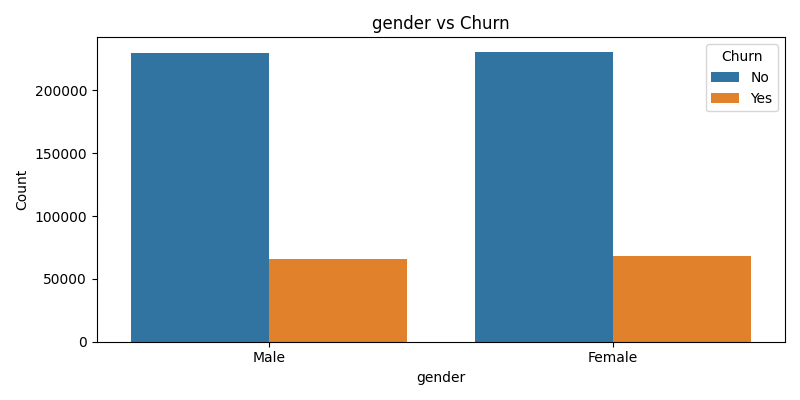

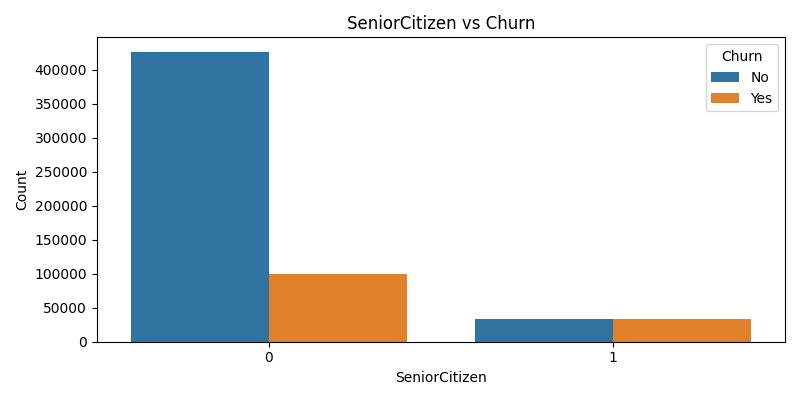

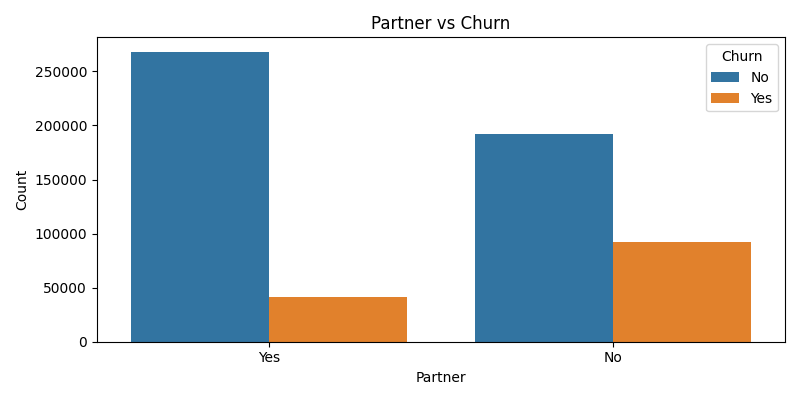

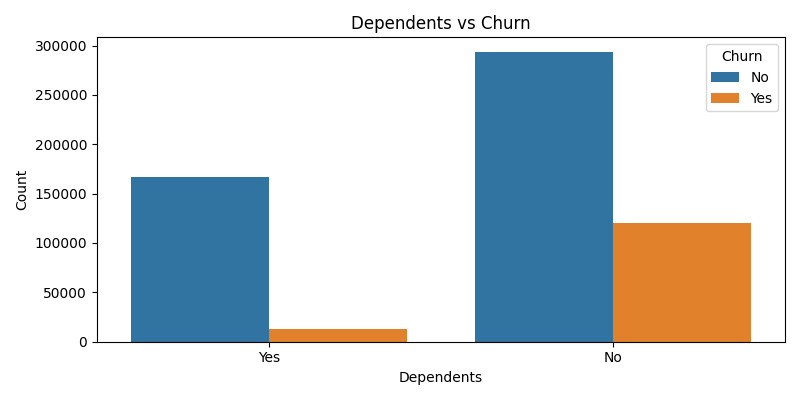

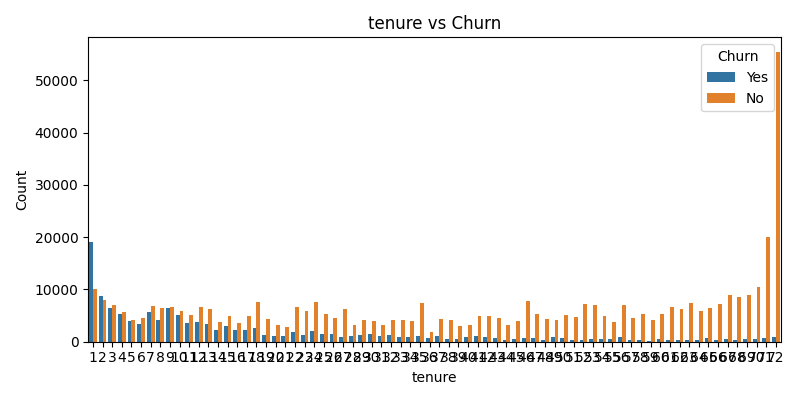

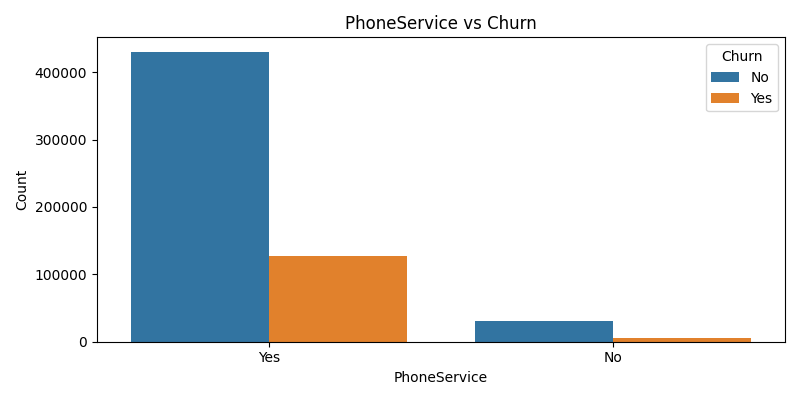

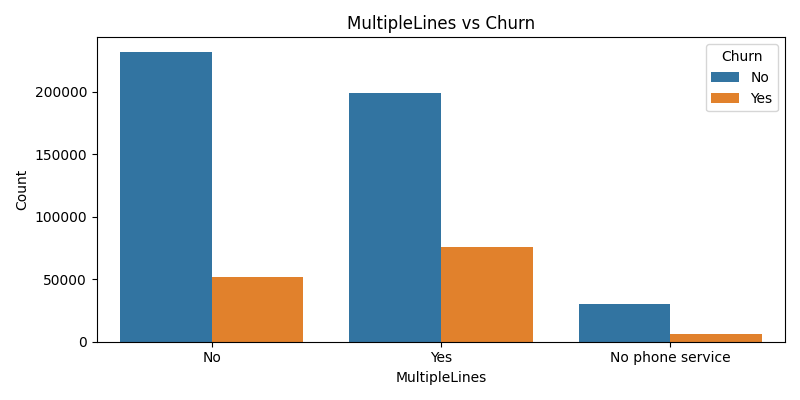

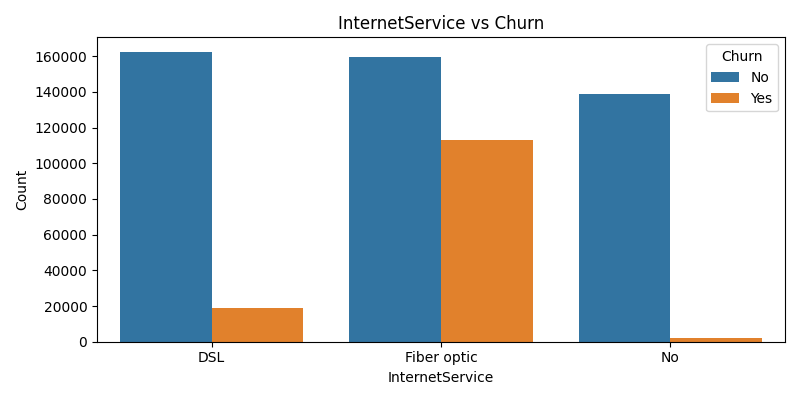

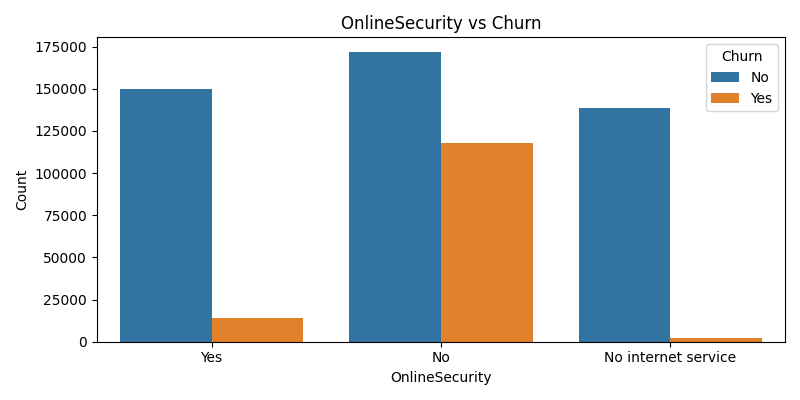

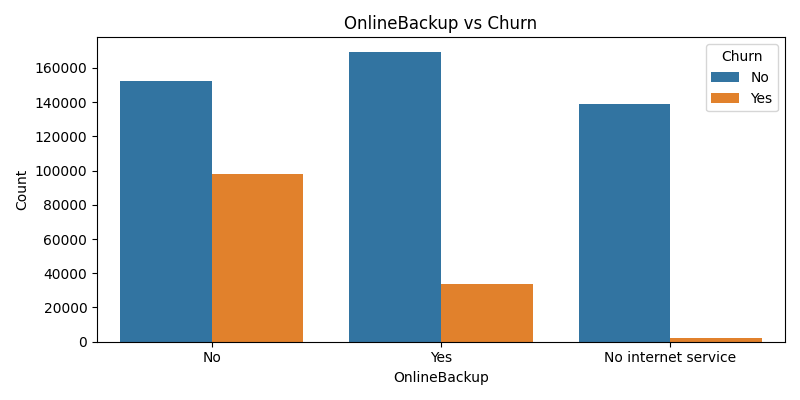

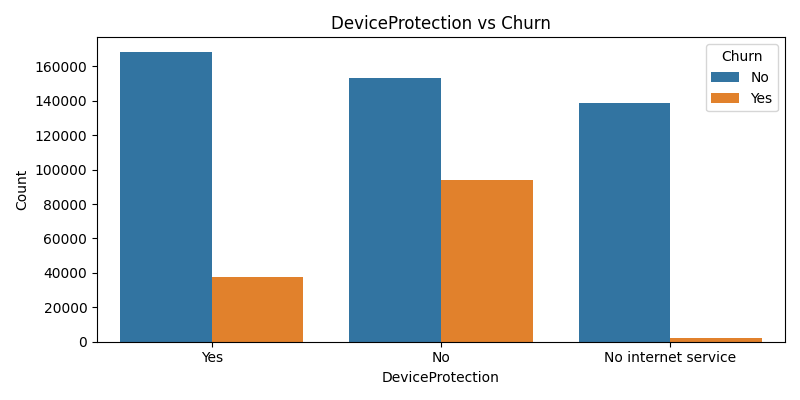

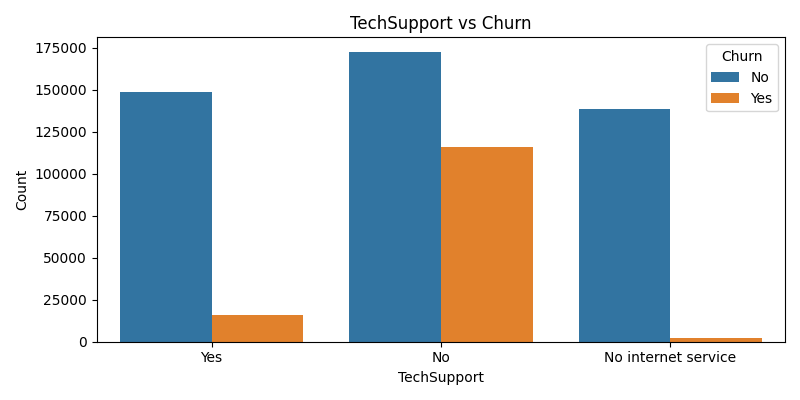

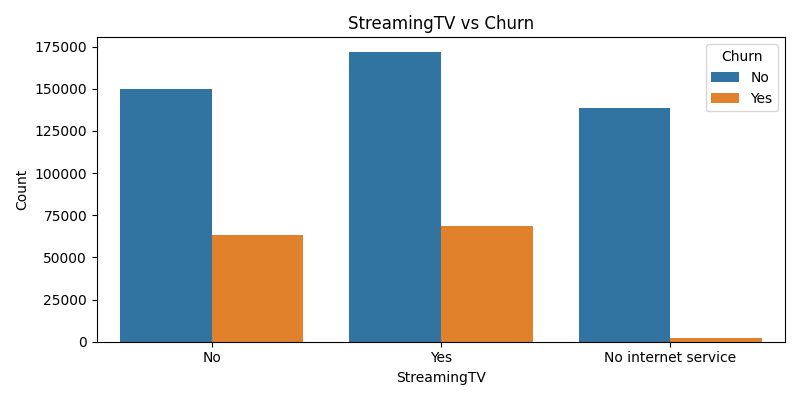

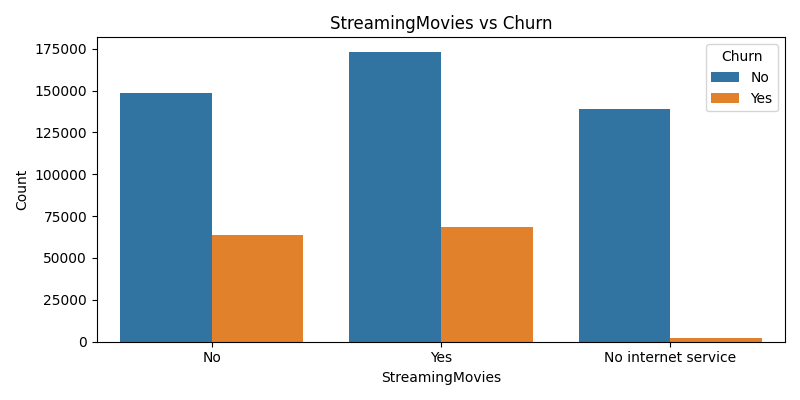

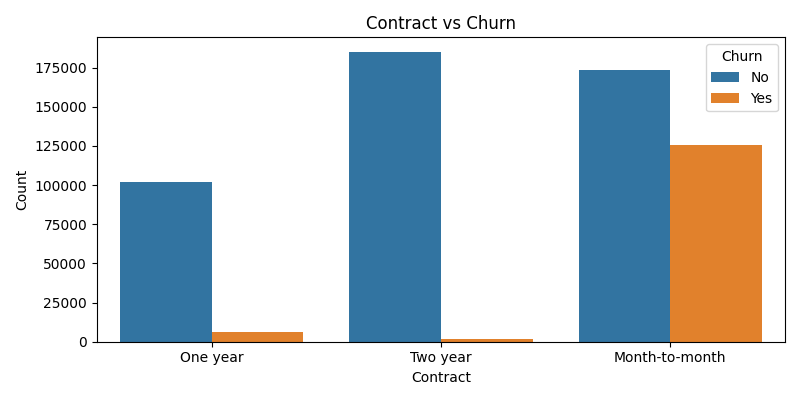

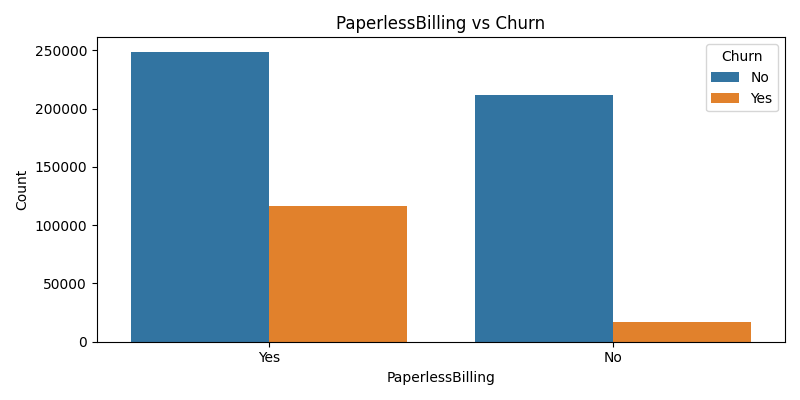

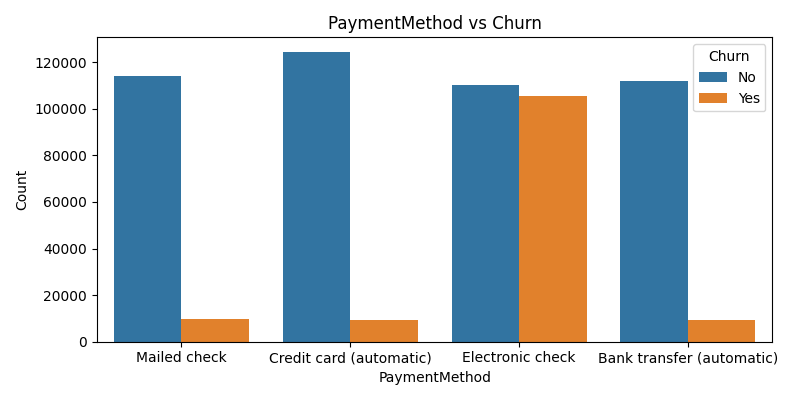

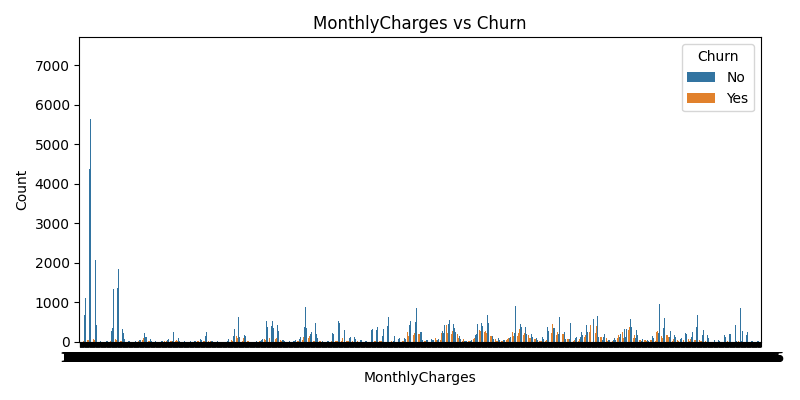

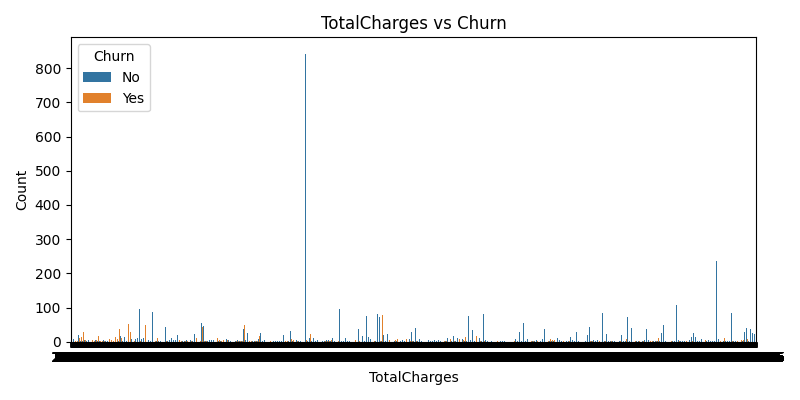

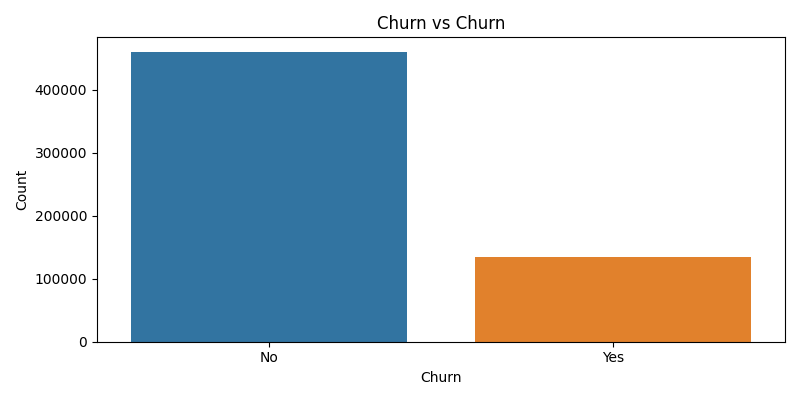

In [ ]:
# 各々の特徴量（genderからTotalCharges）と、目的の変数（Churn）との関係性を確認するためのグラフを作成

# 理想
# 有意差をアスタリスクの数で表示
# アスタリスクの数は、p値の大きさに応じて以下のように設定
# p < 0.001: '***'
# 0.001 <= p < 0.01: '**'
# 0.01 <= p < 0.05: '*'

import io
from IPython.display import Image, display # 
import matplotlib.pyplot as plt
import seaborn as sns

for column in data_train.columns[1:]: # id列を除く全ての列に対してループ
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.countplot(x=column, hue='Churn', data=data_train, ax=ax)
    ax.set_title(f'{column} vs Churn')
    ax.set_xlabel(column)
    ax.set_ylabel('Count')
    if ax.get_legend() is not None: # 凡例が存在する場合にタイトルを設定
        ax.get_legend().set_title('Churn')

    buf = io.BytesIO()
    fig.tight_layout()
    fig.savefig(buf, format='png')
    buf.seek(0)
    display(Image(data=buf.getvalue()))
    plt.close(fig)

# データの統合、分割、削除、新特徴量生成の検討

In [ ]:
# 教師用データとテストデータ、双方にエンジニアリングを行うため、一旦一つに結合する。
data_all = pd.concat([data_train, data_test], sort = False)
data_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 848849 entries, 0 to 254654
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                848849 non-null  int64  
 1   gender            848849 non-null  object 
 2   SeniorCitizen     848849 non-null  int64  
 3   Partner           848849 non-null  object 
 4   Dependents        848849 non-null  object 
 5   tenure            848849 non-null  int64  
 6   PhoneService      848849 non-null  object 
 7   MultipleLines     848849 non-null  object 
 8   InternetService   848849 non-null  object 
 9   OnlineSecurity    848849 non-null  object 
 10  OnlineBackup      848849 non-null  object 
 11  DeviceProtection  848849 non-null  object 
 12  TechSupport       848849 non-null  object 
 13  StreamingTV       848849 non-null  object 
 14  StreamingMovies   848849 non-null  object 
 15  Contract          848849 non-null  object 
 16  PaperlessBilling  848849 

## PhoneService と MultipleLines の統合

In [ ]:
# PhoneService と MultipleLines を1列に統合

required_cols = ["PhoneService", "MultipleLines"]
missing = [c for c in required_cols if c not in data_all.columns]
if missing:
    raise ValueError(f"不足カラムがあります: {missing}")

data_all["PhoneLineStatus"] = np.select(
    [
        data_all["PhoneService"].eq("No"),
        data_all["PhoneService"].eq("Yes") & data_all["MultipleLines"].eq("No"),
        data_all["PhoneService"].eq("Yes") & data_all["MultipleLines"].eq("Yes"),
        data_all["MultipleLines"].eq("No phone service")
    ],
    ["no_phone", "single_line", "multi_line", "no_phone"],
    default="unknown"
)

# 元の2列は統合後に削除
data_all.drop(columns=["PhoneService", "MultipleLines"], inplace=True)

print("PhoneLineStatus を作成し、PhoneService/MultipleLines を削除しました")
print(data_all["PhoneLineStatus"].value_counts(dropna=False))
display(data_all[["PhoneLineStatus"]].head(10))

PhoneLineStatus を作成し、PhoneService/MultipleLines を削除しました
PhoneLineStatus
single_line    403636
multi_line     393430
no_phone        51783
Name: count, dtype: int64


,PhoneLineStatus
0,single_line
1,single_line
2,multi_line
3,single_line
4,single_line
5,single_line
6,single_line
7,multi_line
8,multi_line
9,single_line


## Partner + Dependents の統合検討

In [ ]:
# Partner + Dependents を 1 列に統合
# none / partner_only / dependents_only / family の4カテゴリに整理

data_all["HouseholdType"] = np.select( # 条件と結果のリストを指定して新しい列を作成
    [
        data_all["Partner"].eq("No") & data_all["Dependents"].eq("No"),
        data_all["Partner"].eq("Yes") & data_all["Dependents"].eq("No"),
        data_all["Partner"].eq("No") & data_all["Dependents"].eq("Yes"),
        data_all["Partner"].eq("Yes") & data_all["Dependents"].eq("Yes")
    ],
    ["none", "partner_only", "dependents_only", "family"],
    default="unknown"
)

# 元の2列は統合後に削除
data_all.drop(columns=["Partner", "Dependents"], inplace=True)

print("HouseholdType を作成し、Partner/Dependents を削除しました")
print(data_all["HouseholdType"].value_counts(dropna=False))
display(data_all[["HouseholdType"]].head(10))

HouseholdType を作成し、Partner/Dependents を削除しました
HouseholdType
none               385522
family             238401
partner_only       205856
dependents_only     19070
Name: count, dtype: int64


,HouseholdType
0,family
1,family
2,partner_only
3,none
4,none
5,family
6,family
7,partner_only
8,none
9,none


In [ ]:
data_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 848849 entries, 0 to 254654
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                848849 non-null  int64  
 1   gender            848849 non-null  object 
 2   SeniorCitizen     848849 non-null  int64  
 3   tenure            848849 non-null  int64  
 4   InternetService   848849 non-null  object 
 5   OnlineSecurity    848849 non-null  object 
 6   OnlineBackup      848849 non-null  object 
 7   DeviceProtection  848849 non-null  object 
 8   TechSupport       848849 non-null  object 
 9   StreamingTV       848849 non-null  object 
 10  StreamingMovies   848849 non-null  object 
 11  Contract          848849 non-null  object 
 12  PaperlessBilling  848849 non-null  object 
 13  PaymentMethod     848849 non-null  object 
 14  MonthlyCharges    848849 non-null  float64
 15  TotalCharges      848849 non-null  float64
 16  Churn             594194 

## InternetService の　6つの付帯サービスを統合検討

In [ ]:
# # === 重要な質問への検証 ===
# # Q1: Streaming系とSupport系は似た傾向か？ → Yes/No別のChurn率を比較
# # Q2: InternetServiceタイプは重要か？特にFiber opticか？

# churn_train = data_all[data_all['Churn'].notna()].copy()

# # 1. Streaming/Support のYes・No別のChurn率（傾向が似ているか）
# print("=== Streaming TV vs OnlineSecurity (傾向比較) ===")
# print("StreamingTV別Churn率:")
# print(churn_train.groupby('StreamingTV')['Churn'].apply(lambda x: (x=='Yes').sum() / len(x)).round(3))
# print("\nOnlineSecurity別Churn率:")
# print(churn_train.groupby('OnlineSecurity')['Churn'].apply(lambda x: (x=='Yes').sum() / len(x)).round(3))

# # 2. InternetService別Churn率（Fiber opticが重要か？）
# print("\n\n=== InternetService別Churn率 ===")
# internet_churn_rate = churn_train.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').sum() / len(x)).round(3)
# print(internet_churn_rate)
# print(f"\n→ Fiber opticのChurn率がNo internet serviceより著しく高い理由を調査")

# # 3. Fiber opticでのStreaming/Supportの保護度合い
# print("\n=== Fiber opticにおけるStreaming/Supportの保護効果 ===")
# fiber = churn_train[churn_train['InternetService'] == 'Fiber optic']
# print(f"Fiber optic顧客総数: {len(fiber)}, 全体Churn率: {(fiber['Churn']=='Yes').sum()/len(fiber):.3f}")
# print("\nStreaming TVあり vs なし:")
# print(fiber.groupby('StreamingTV')['Churn'].apply(lambda x: (x=='Yes').sum() / len(x)).round(3))
# print("\nOnlineSecurity ありvs なし:")
# print(fiber.groupby('OnlineSecurity')['Churn'].apply(lambda x: (x=='Yes').sum() / len(x)).round(3))

=== Streaming TV vs OnlineSecurity (傾向比較) ===
StreamingTV別Churn率:
StreamingTV
No                     0.297
No internet service    0.014
Yes                    0.285
Name: Churn, dtype: float64

OnlineSecurity別Churn率:
OnlineSecurity
No                     0.406
No internet service    0.014
Yes                    0.087
Name: Churn, dtype: float64


=== InternetService別Churn率 ===
InternetService
DSL            0.103
Fiber optic    0.415
No             0.014
Name: Churn, dtype: float64

→ Fiber opticのChurn率がNo internet serviceより著しく高い理由を調査

=== Fiber opticにおけるStreaming/Supportの保護効果 ===
Fiber optic顧客総数: 272386, 全体Churn率: 0.415

Streaming TVあり vs なし:
StreamingTV
No     0.454
Yes    0.390
Name: Churn, dtype: float64

OnlineSecurity ありvs なし:
OnlineSecurity
No     0.489
Yes    0.167
Name: Churn, dtype: float64


In [ ]:
# # === "No internet service"の扱いと、Streaming系統合の有効性確認 ===

# # 1. "No internet service"がどの列に出現するか
# print("=== 'No internet service' が出現する列 ===")
# no_internet_svc_count = {}
# for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
#     count = (data_all[col] == 'No internet service').sum()
#     if count > 0:
#         no_internet_svc_count[col] = count
#         print(f"{col}: {count} 件")

# # InternetService="No"の顧客数と比較
# internet_service_no = (data_all['InternetService'] == 'No').sum()
# print(f"\nInternetService='No'の顧客数: {internet_service_no}")
# print("→ 'No internet service'値はInternetService='No'と完全に対応するか確認")

# # 2. Streaming系統合の有効性
# # StreamingTVとStreamingMoviesの共起パターンを見る
# print("\n\n=== Streaming系の共起パターン ===")
# streaming_combo = pd.crosstab(
#     data_all['StreamingTV'], 
#     data_all['StreamingMovies'], 
#     margins=True
# )
# print(streaming_combo)

# print("\nStreaming系のChurn率（共起パターン別）:")
# streaming_churn = data_all[data_all['Churn'].notna()].groupby(['StreamingTV', 'StreamingMovies'])['Churn'].apply(lambda x: (x=='Yes').sum() / len(x)).round(3)
# print(streaming_churn)

# print("\n→ Streaming TVとMovieの組み合わせでChurn傾向に違いがあるか？")

=== 'No internet service' が出現する列 ===
OnlineSecurity: 201039 件
OnlineBackup: 201039 件
DeviceProtection: 201039 件
TechSupport: 201039 件
StreamingTV: 201039 件
StreamingMovies: 201039 件

InternetService='No'の顧客数: 201039
→ 'No internet service'値はInternetService='No'と完全に対応するか確認


=== Streaming系の共起パターン ===
StreamingMovies          No  No internet service     Yes     All
StreamingTV                                                     
No                   231538                    0   71627  303165
No internet service       0               201039       0  201039
Yes                   69819                    0  274826  344645
All                  301357               201039  346453  848849

Streaming系のChurn率（共起パターン別）:
StreamingTV          StreamingMovies    
No                   No                     0.289
                     Yes                    0.324
No internet service  No internet service    0.014
Yes                  No                     0.333
                     Yes               

In [ ]:
# # InternetService + 6つの付帯サービスを統合
# # 7列を圧縮して、情報をまとめた特徴量を作る

# def add_internet_bundle_features(df_in):
#     df = df_in.copy()

#     service_cols = [
#         "OnlineSecurity", "OnlineBackup", "DeviceProtection",
#         "TechSupport", "StreamingTV", "StreamingMovies"
#     ]
#     support_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
#     streaming_cols = ["StreamingTV", "StreamingMovies"]

#     # Internet接続の有無
#     df["HasInternet"] = np.where(df["InternetService"].eq("No"), "No", "Yes") # InternetServiceがNoの行はHasInternetもNo、それ以外はYes

#     # No internet service を No に正規化（接続していない場合は付帯サービス非利用として扱う）
#     for c in service_cols:
#         df[c + "_bin"] = np.where(df[c].eq("Yes"), 1, 0)

#     # 付帯サービス利用本数
#     df["InternetAddonCount"] = df[[c + "_bin" for c in service_cols]].sum(axis=1)
#     df["SupportAddonCount"] = df[[c + "_bin" for c in support_cols]].sum(axis=1)
#     df["StreamingAddonCount"] = df[[c + "_bin" for c in streaming_cols]].sum(axis=1)

#     # まとまりカテゴリ
#     df["SupportBundle"] = np.select(
#         [
#             df["HasInternet"].eq("No"),
#             df["SupportAddonCount"].eq(0),
#             df["SupportAddonCount"].between(1, 2),
#             df["SupportAddonCount"].ge(3),
#         ],
#         ["no_internet", "none", "basic", "full"],
#         default="unknown"
#     )

#     df["StreamingBundle"] = np.select(
#         [
#             df["HasInternet"].eq("No"),
#             df["StreamingAddonCount"].eq(0),
#             df["StreamingAddonCount"].eq(1),
#             df["StreamingAddonCount"].eq(2),
#         ],
#         ["no_internet", "none", "one", "both"],
#         default="unknown"
#     )

#     # 元の7列と中間bin列は削除
#     drop_cols = service_cols + ["InternetService"] + [c + "_bin" for c in service_cols]
#     df.drop(columns=drop_cols, inplace=True)

#     return df

# if "data_all" in globals():
#     data_all = add_internet_bundle_features(data_all)
#     print("InternetService系の統合を data_all に適用しました")
#     display(data_all[["HasInternet", "InternetAddonCount", "SupportBundle", "StreamingBundle"]].head())
# else:
#     print("data_all が未定義です。先に data_all = pd.concat([data_train, data_test], sort=False) を実行してください。")

## PaymentMethod を2軸に分解して再統合
元4カテゴリをそのまま使うより、auto_pay(自動支払いか) と payment_channel(check/card/bank) に分ける
README上の「Electronic checkだけ高リスク」を拾いやすい

## Contract + PaperlessBilling を統合
作る列: contract_billing_profile
例: month_to_month + paperless の組み合わせは churn 高リスク帯になりやすい

## TotalCharges, tenure, MonthlyChargesの削減検討

rows used: 594194
corr: 0.992064
mae : 151.0974
within 1.0: 6.10%


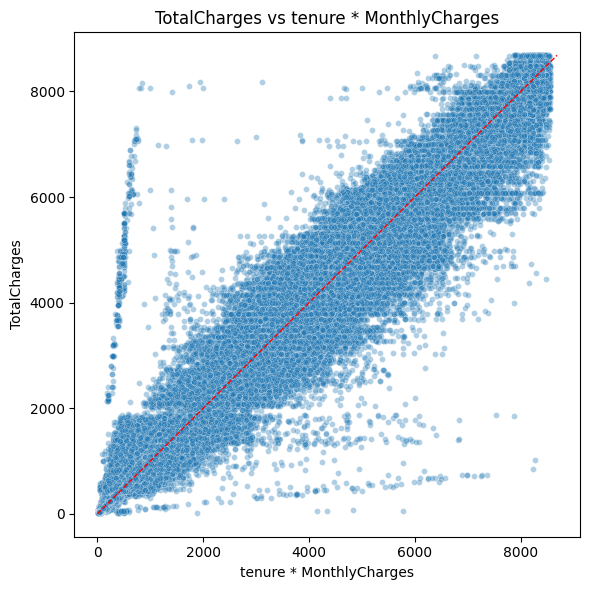

In [ ]:
# # TotalCharges = tenure * MonthlyCharges は成立しているのか？散布図で確認
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# check_df = data_train.copy()
# check_df["TotalCharges_num"] = pd.to_numeric(check_df["TotalCharges"], errors="coerce") # TotalChargesを数値に変換（変換できない値はNaNになる）
# check_df["expected_total"] = check_df["tenure"] * check_df["MonthlyCharges"]
# check_df = check_df.dropna(subset=["TotalCharges_num", "expected_total"])
# check_df["abs_error"] = (check_df["TotalCharges_num"] - check_df["expected_total"]).abs()

# print(f"rows used: {len(check_df)}")
# print(f"corr: {check_df['TotalCharges_num'].corr(check_df['expected_total']):.6f}")
# print(f"mae : {check_df['abs_error'].mean():.4f}") # 平均絶対誤差
# print(f"within 1.0: {(check_df['abs_error'] <= 1.0).mean():.2%}") # 誤差が1.0以下の割合

# plt.figure(figsize=(6, 6))
# sns.scatterplot(
#     data=check_df, # 件数が多い場合はランダムに3000件を抽出してプロット　.sample(min(5000, len(check_df)), random_state=42)
#     x="expected_total",
#     y="TotalCharges_num",
#     alpha=0.35,
#     s=18
# )
# max_val = max(check_df["expected_total"].max(), check_df["TotalCharges_num"].max())
# plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1) # y=xの線を追加
# plt.title("TotalCharges vs tenure * MonthlyCharges")
# plt.xlabel("tenure * MonthlyCharges")
# plt.ylabel("TotalCharges")
# plt.tight_layout()
# plt.show()

# # 単純なTotalChargesとtenure * MonthlyChargesにはなっていない

In [ ]:
# # 特徴量削減の判断: AUC と LogLoss の両方で比較（5-fold CV + 95%CI）
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import StratifiedKFold
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.impute import SimpleImputer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import roc_auc_score, log_loss

# # ---- 1) 学習データの準備 ----
# df = data_train.copy()
# target_col = "Churn"
# y = df[target_col].map({"No": 0, "Yes": 1}) if df[target_col].dtype == "object" else df[target_col]

# drop_cols = [target_col]
# if "id" in df.columns:
#     drop_cols.append("id")
# all_features = [c for c in df.columns if c not in drop_cols]

# # ---- 2) 比較シナリオ ----
# scenarios = {
#     "both_all": all_features,
#     "drop_totalcharges": [c for c in all_features if c != "TotalCharges"],
#     "drop_tenure": [c for c in all_features if c != "tenure"],
#     "drop_monthly": [c for c in all_features if c != "MonthlyCharges"],
# }

# # ---- 3) パイプライン作成関数 ----
# def make_model(feature_list):
#     X_tmp = df[feature_list]
#     cat_cols = X_tmp.select_dtypes(include=["object", "category"]).columns.tolist()
#     num_cols = [c for c in X_tmp.columns if c not in cat_cols]

#     pre = ColumnTransformer(
#         transformers=[
#             ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
#             ("cat", Pipeline([
#                 ("imp", SimpleImputer(strategy="most_frequent")),
#                 ("ohe", OneHotEncoder(handle_unknown="ignore")),
#             ]), cat_cols),
#         ],
#         remainder="drop",
#     )

#     return Pipeline([
#         ("pre", pre),
#         ("clf", LogisticRegression(max_iter=3000, random_state=42)),
#     ])

# # ---- 4) 同一splitでAUC/LogLossを同時評価 ----
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# fold_metrics = {name: {"auc": [], "logloss": []} for name in scenarios}

# for tr_idx, va_idx in cv.split(df[all_features], y):
#     y_train, y_valid = y.iloc[tr_idx], y.iloc[va_idx]

#     for name, feats in scenarios.items():
#         X_train = df.iloc[tr_idx][feats]
#         X_valid = df.iloc[va_idx][feats]

#         model = make_model(feats)
#         model.fit(X_train, y_train)
#         proba = model.predict_proba(X_valid)[:, 1]

#         fold_metrics[name]["auc"].append(roc_auc_score(y_valid, proba))
#         fold_metrics[name]["logloss"].append(log_loss(y_valid, proba))

# # ---- 5) 集計 ----
# def mean_ci95(arr):
#     arr = np.array(arr, dtype=float)
#     mean = arr.mean()
#     se = arr.std(ddof=1) / np.sqrt(len(arr))
#     low = mean - 1.96 * se
#     high = mean + 1.96 * se
#     return mean, low, high

# rows = []
# for name in scenarios:
#     auc_m, auc_l, auc_h = mean_ci95(fold_metrics[name]["auc"])
#     ll_m, ll_l, ll_h = mean_ci95(fold_metrics[name]["logloss"])
#     rows.append({
#         "scenario": name,
#         "AUC_mean": auc_m,
#         "AUC_95CI": f"[{auc_l:.5f}, {auc_h:.5f}]",
#         "LogLoss_mean": ll_m,
#         "LogLoss_95CI": f"[{ll_l:.5f}, {ll_h:.5f}]",
#     })

# result_df = pd.DataFrame(rows).sort_values("scenario").reset_index(drop=True)
# print("=== Scenario Metrics ===")
# display(result_df)

# # ---- 6) both_allとの差分（ペア比較） ----
# base_auc = np.array(fold_metrics["both_all"]["auc"])
# base_ll = np.array(fold_metrics["both_all"]["logloss"])

# diff_rows = []
# for name in scenarios:
#     if name == "both_all":
#         continue

#     # AUCは「both - other」が正なら、otherが悪化
#     delta_auc = base_auc - np.array(fold_metrics[name]["auc"])
#     # LogLossは「other - both」が正なら、otherが悪化
#     delta_ll = np.array(fold_metrics[name]["logloss"]) - base_ll

#     auc_m, auc_l, auc_h = mean_ci95(delta_auc)
#     ll_m, ll_l, ll_h = mean_ci95(delta_ll)

#     diff_rows.append({
#         "compare_to_both": name,
#         "Delta_AUC_mean": auc_m,
#         "Delta_AUC_95CI": f"[{auc_l:.5f}, {auc_h:.5f}]",
#         "Delta_LogLoss_mean": ll_m,
#         "Delta_LogLoss_95CI": f"[{ll_l:.5f}, {ll_h:.5f}]",
#     })

# diff_df = pd.DataFrame(diff_rows)
# print("\n=== Paired Delta vs both_all (positive = worse than both_all) ===")
# display(diff_df)

# # ---- 7) 実務判断ルール（目安） ----
# # 1) 95%CIが0をまたがない -> 統計的に差が安定
# # 2) 実務閾値: Delta_AUC > 0.002 or Delta_LogLoss > 0.003 を悪化とみなす
# print("\n=== Quick Decision Guide ===")
# for _, r in diff_df.iterrows():
#     msg = []
#     if r["Delta_AUC_mean"] > 0.002:
#         msg.append("AUC悪化が実務閾値を超える")
#     if r["Delta_LogLoss_mean"] > 0.003:
#         msg.append("LogLoss悪化が実務閾値を超える")
#     if not msg:
#         msg.append("削減候補（性能悪化が小さい）")

#     print(f"- {r['compare_to_both']}: " + " / ".join(msg))

=== Scenario Metrics ===


,scenario,AUC_mean,AUC_95CI,LogLoss_mean,LogLoss_95CI
0,both_all,0.907940,"[0.90688, 0.90900]",0.312387,"[0.31086, 0.31392]"
1,drop_monthly,0.907956,"[0.90690, 0.90902]",0.312371,"[0.31084, 0.31390]"
2,drop_tenure,0.903579,"[0.90231, 0.90485]",0.318474,"[0.31665, 0.32030]"
3,drop_totalcharges,0.906915,"[0.90580, 0.90803]",0.313373,"[0.31174, 0.31501]"



=== Paired Delta vs both_all (positive = worse than both_all) ===


,compare_to_both,Delta_AUC_mean,Delta_AUC_95CI,Delta_LogLoss_mean,Delta_LogLoss_95CI
0,drop_totalcharges,0.001026,"[0.00095, 0.00110]",0.000985,"[0.00087, 0.00110]"
1,drop_tenure,0.004361,"[0.00410, 0.00462]",0.006087,"[0.00575, 0.00643]"
2,drop_monthly,-0.000016,"[-0.00002, -0.00001]",-0.000016,"[-0.00002, -0.00001]"



=== Quick Decision Guide ===
- drop_totalcharges: 削減候補（性能悪化が小さい）
- drop_tenure: AUC悪化が実務閾値を超える / LogLoss悪化が実務閾値を超える
- drop_monthly: 削減候補（性能悪化が小さい）


In [ ]:
# # LightGBM版で同じ比較（AUC + LogLoss, 5-fold CV + 95%CI）
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import StratifiedKFold
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.impute import SimpleImputer
# from sklearn.metrics import roc_auc_score, log_loss
# from lightgbm import LGBMClassifier

# # ---- 1) データ準備 ----
# df_lgb = data_train.copy()
# target_col = "Churn"
# y_lgb = df_lgb[target_col].map({"No": 0, "Yes": 1}) if df_lgb[target_col].dtype == "object" else df_lgb[target_col]

# drop_cols = [target_col]
# if "id" in df_lgb.columns:
#     drop_cols.append("id")
# all_features_lgb = [c for c in df_lgb.columns if c not in drop_cols]

# scenarios_lgb = {
#     "both_all": all_features_lgb,
#     "drop_totalcharges": [c for c in all_features_lgb if c != "TotalCharges"],
#     "drop_tenure": [c for c in all_features_lgb if c != "tenure"],
#     "drop_monthly": [c for c in all_features_lgb if c != "MonthlyCharges"],
# }

# # ---- 2) モデル作成関数 ----
# def make_lgb_model(feature_list):
#     X_tmp = df_lgb[feature_list]
#     cat_cols = X_tmp.select_dtypes(include=["object", "category"]).columns.tolist()
#     num_cols = [c for c in X_tmp.columns if c not in cat_cols]

#     pre = ColumnTransformer(
#         transformers=[
#             ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
#             ("cat", Pipeline([
#                 ("imp", SimpleImputer(strategy="most_frequent")),
#                 ("ohe", OneHotEncoder(handle_unknown="ignore")),
#             ]), cat_cols),
#         ],
#         remainder="drop",
#     )

#     clf = LGBMClassifier(
#         objective="binary",
#         n_estimators=250,
#         learning_rate=0.05,
#         num_leaves=31,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         reg_alpha=0.0,
#         reg_lambda=0.0,
#         random_state=42,
#         n_jobs=-1,
#         verbosity=-1,
#     )

#     return Pipeline([
#         ("pre", pre),
#         ("clf", clf),
#     ])

# # ---- 3) CV評価 ----
# cv_lgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# fold_metrics_lgb = {name: {"auc": [], "logloss": []} for name in scenarios_lgb}

# for tr_idx, va_idx in cv_lgb.split(df_lgb[all_features_lgb], y_lgb):
#     y_train, y_valid = y_lgb.iloc[tr_idx], y_lgb.iloc[va_idx]

#     for name, feats in scenarios_lgb.items():
#         X_train = df_lgb.iloc[tr_idx][feats]
#         X_valid = df_lgb.iloc[va_idx][feats]

#         model = make_lgb_model(feats)
#         model.fit(X_train, y_train)
#         proba = model.predict_proba(X_valid)[:, 1]

#         fold_metrics_lgb[name]["auc"].append(roc_auc_score(y_valid, proba))
#         fold_metrics_lgb[name]["logloss"].append(log_loss(y_valid, proba))

# # ---- 4) 集計関数 ----
# def mean_ci95(arr):
#     arr = np.array(arr, dtype=float)
#     mean = arr.mean()
#     se = arr.std(ddof=1) / np.sqrt(len(arr))
#     low = mean - 1.96 * se
#     high = mean + 1.96 * se
#     return mean, low, high

# rows_lgb = []
# for name in scenarios_lgb:
#     auc_m, auc_l, auc_h = mean_ci95(fold_metrics_lgb[name]["auc"])
#     ll_m, ll_l, ll_h = mean_ci95(fold_metrics_lgb[name]["logloss"])
#     rows_lgb.append({
#         "scenario": name,
#         "AUC_mean": auc_m,
#         "AUC_95CI": f"[{auc_l:.5f}, {auc_h:.5f}]",
#         "LogLoss_mean": ll_m,
#         "LogLoss_95CI": f"[{ll_l:.5f}, {ll_h:.5f}]",
#     })

# result_lgb_df = pd.DataFrame(rows_lgb).sort_values("scenario").reset_index(drop=True)
# print("=== LightGBM Scenario Metrics ===")
# display(result_lgb_df)

# # ---- 5) both_allとの差分 ----
# base_auc_lgb = np.array(fold_metrics_lgb["both_all"]["auc"])
# base_ll_lgb = np.array(fold_metrics_lgb["both_all"]["logloss"])

# diff_rows_lgb = []
# for name in scenarios_lgb:
#     if name == "both_all":
#         continue

#     delta_auc = base_auc_lgb - np.array(fold_metrics_lgb[name]["auc"])
#     delta_ll = np.array(fold_metrics_lgb[name]["logloss"]) - base_ll_lgb

#     auc_m, auc_l, auc_h = mean_ci95(delta_auc)
#     ll_m, ll_l, ll_h = mean_ci95(delta_ll)

#     diff_rows_lgb.append({
#         "compare_to_both": name,
#         "Delta_AUC_mean": auc_m,
#         "Delta_AUC_95CI": f"[{auc_l:.5f}, {auc_h:.5f}]",
#         "Delta_LogLoss_mean": ll_m,
#         "Delta_LogLoss_95CI": f"[{ll_l:.5f}, {ll_h:.5f}]",
#     })

# diff_lgb_df = pd.DataFrame(diff_rows_lgb)
# print("\n=== LightGBM Paired Delta vs both_all (positive = worse than both_all) ===")
# display(diff_lgb_df)

# print("\n=== LightGBM Quick Decision Guide ===")
# for _, r in diff_lgb_df.iterrows():
#     msg = []
#     if r["Delta_AUC_mean"] > 0.002:
#         msg.append("AUC悪化が実務閾値を超える")
#     if r["Delta_LogLoss_mean"] > 0.003:
#         msg.append("LogLoss悪化が実務閾値を超える")
#     if not msg:
#         msg.append("削減候補（性能悪化が小さい）")
#     print(f"- {r['compare_to_both']}: " + " / ".join(msg))

=== LightGBM Scenario Metrics ===


,scenario,AUC_mean,AUC_95CI,LogLoss_mean,LogLoss_95CI
0,both_all,0.915469,"[0.91451, 0.91643]",0.299205,"[0.29767, 0.30074]"
1,drop_monthly,0.915326,"[0.91435, 0.91630]",0.299424,"[0.29786, 0.30099]"
2,drop_tenure,0.913538,"[0.91247, 0.91461]",0.302177,"[0.30049, 0.30386]"
3,drop_totalcharges,0.913669,"[0.91265, 0.91469]",0.301996,"[0.30040, 0.30359]"



=== LightGBM Paired Delta vs both_all (positive = worse than both_all) ===


,compare_to_both,Delta_AUC_mean,Delta_AUC_95CI,Delta_LogLoss_mean,Delta_LogLoss_95CI
0,drop_totalcharges,0.001800,"[0.00173, 0.00187]",0.002791,"[0.00271, 0.00287]"
1,drop_tenure,0.001931,"[0.00180, 0.00206]",0.002973,"[0.00278, 0.00316]"
2,drop_monthly,0.000144,"[0.00010, 0.00019]",0.000219,"[0.00015, 0.00029]"



=== LightGBM Quick Decision Guide ===
- drop_totalcharges: 削減候補（性能悪化が小さい）
- drop_tenure: 削減候補（性能悪化が小さい）
- drop_monthly: 削減候補（性能悪化が小さい）




### 結果（Logistic Regression, 5-fold）

both_all
AUC = 0.907940, LogLoss = 0.312387
drop_totalcharges
Delta AUC = +0.001026, Delta LogLoss = +0.000985
drop_tenure
Delta AUC = +0.004361, Delta LogLoss = +0.006087
drop_monthly
Delta AUC = -0.000016, Delta LogLoss = -0.000016

AUC差分は正なら削除側が悪化。
LogLoss差分は正なら削除側が悪化。
今回は各差分の95%CIも出しており、差の安定性を確認済み。


TotalChargesは削減候補
    悪化は小さく、実務的には削ってもよい可能性が高い。
MonthlyChargesも削減候補
    今回のモデルでは削ってもほぼ同等（わずかに改善）。




### 結果（LightGBM, 5-fold）

both_all
AUC 0.915469 / LogLoss 0.299205
drop_totalcharges
Delta AUC +0.001800 / Delta LogLoss +0.002791
drop_tenure
Delta AUC +0.001931 / Delta LogLoss +0.002973
drop_monthly
Delta AUC +0.000144 / Delta LogLoss +0.000219
解釈

3つとも削ると悪化（Deltaが全部正）。
ただ悪化幅は小さく、実務閾値（AUC 0.002 / LogLoss 0.003）だと「削減候補」に見えるものもあり。
モデル簡素化を優先するなら、影響最小の順は MonthlyCharges → TotalCharges ≈ tenure です。


### まとめ
ロジスティック回帰では tenure を落とすと悪化が大きかった。
LightGBMでは悪化は小さい。
つまり「どの特徴量を減らせるか」はモデル依存なので使用モデル基準で判断する。

最終的に使うモデル（LightGBM）で反復CV（例: 5-fold × 3 repeats）にしてCIをさらに安定化。
その結果で「本当に削る列」を最終確定。

## MonthlyChargesとChurnの周期性の検討

rows (top 50% MonthlyCharges): 297656
estimated dominant period: 22.325 MonthlyCharges units
permutation p-value for periodicity: 0.5070
=> 明確な周期性は確認できない（見た目の波の可能性）


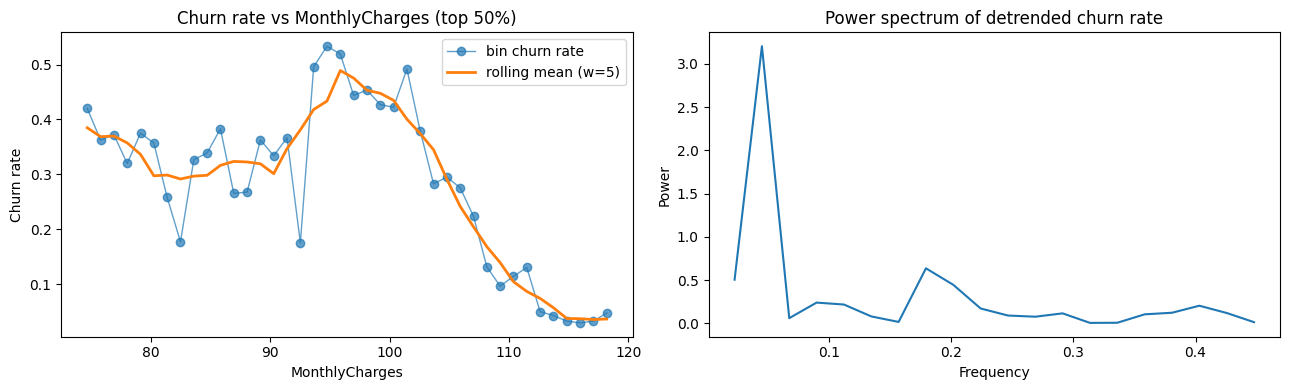

In [ ]:
# # MonthlyChargesとChurnに周期性があるかを確認
# # 条件: MonthlyChargesの上位50%に限定
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # --- 1) データ準備 ---
# df_period = data_train.copy()
# df_period["Churn_bin"] = df_period["Churn"].map({"No": 0, "Yes": 1})

# q50 = df_period["MonthlyCharges"].quantile(0.5)
# df_top = df_period[df_period["MonthlyCharges"] >= q50].copy()

# # --- 2) MonthlyChargesを等間隔binにして、binごとのChurn率を算出 ---
# # 周波数解析のために等間隔binを使う
# n_bins = 40
# bin_edges = np.linspace(df_top["MonthlyCharges"].min(), df_top["MonthlyCharges"].max(), n_bins + 1)
# df_top["charge_bin"] = pd.cut(df_top["MonthlyCharges"], bins=bin_edges, include_lowest=True)

# agg = (
#     df_top.groupby("charge_bin", observed=False)
#     .agg(churn_rate=("Churn_bin", "mean"), n=("Churn_bin", "size"))
#     .reset_index()
# )
# agg = agg.dropna(subset=["churn_rate"]).copy()
# agg["bin_center"] = [iv.mid for iv in agg["charge_bin"]]

# # --- 3) 見た目の波を確認（生データ + 平滑化） ---
# agg = agg.sort_values("bin_center")
# agg["rolling"] = agg["churn_rate"].rolling(window=5, center=True, min_periods=1).mean()

# # --- 4) 周期性の簡易検定（FFT + permutation） ---
# y = agg["churn_rate"].to_numpy()
# x = agg["bin_center"].to_numpy()

# # 緩いトレンドを除去してから周波数成分を見る
# deg = 2 if len(x) >= 8 else 1
# trend = np.polyval(np.polyfit(x, y, deg=deg), x)
# resid = y - trend
# resid = resid - resid.mean()

# # サンプル間隔（bin幅）
# dx = np.mean(np.diff(x))
# freq = np.fft.rfftfreq(len(resid), d=dx)
# power = np.abs(np.fft.rfft(resid)) ** 2

# # 0周波数（直流成分）は除外
# if len(power) > 1:
#     peak_idx = np.argmax(power[1:]) + 1
#     obs_peak_power = power[peak_idx]
#     peak_freq = freq[peak_idx]
#     est_period = np.inf if peak_freq == 0 else 1.0 / peak_freq
# else:
#     obs_peak_power = np.nan
#     peak_freq = np.nan
#     est_period = np.nan

# # permutationで「偶然の波」に対するp値を計算
# rng = np.random.default_rng(42)
# n_perm = 500
# perm_peaks = []
# for _ in range(n_perm):
#     y_perm = rng.permutation(y)
#     trend_perm = np.polyval(np.polyfit(x, y_perm, deg=deg), x)
#     resid_perm = y_perm - trend_perm
#     resid_perm = resid_perm - resid_perm.mean()
#     pw = np.abs(np.fft.rfft(resid_perm)) ** 2
#     perm_peaks.append(np.max(pw[1:]) if len(pw) > 1 else 0.0)

# perm_peaks = np.array(perm_peaks)
# p_value = (np.sum(perm_peaks >= obs_peak_power) + 1) / (n_perm + 1)

# print(f"rows (top 50% MonthlyCharges): {len(df_top)}")
# print(f"estimated dominant period: {est_period:.3f} MonthlyCharges units")
# print(f"permutation p-value for periodicity: {p_value:.4f}")
# if p_value < 0.05:
#     print("=> 周期性がある可能性が高い（統計的に有意）")
# else:
#     print("=> 明確な周期性は確認できない（見た目の波の可能性）")

# # --- 5) 可視化 ---
# fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# axes[0].plot(agg["bin_center"], agg["churn_rate"], marker="o", linewidth=1, alpha=0.7, label="bin churn rate")
# axes[0].plot(agg["bin_center"], agg["rolling"], linewidth=2, label="rolling mean (w=5)")
# axes[0].set_title("Churn rate vs MonthlyCharges (top 50%)")
# axes[0].set_xlabel("MonthlyCharges")
# axes[0].set_ylabel("Churn rate")
# axes[0].legend()

# axes[1].plot(freq[1:], power[1:], linewidth=1.5)
# axes[1].set_title("Power spectrum of detrended churn rate")
# axes[1].set_xlabel("Frequency")
# axes[1].set_ylabel("Power")

# plt.tight_layout()
# plt.show()

MonthlyCharges 50-80% range: [74.100, 95.000]
rows in band: 179055


,n_bins,p_value,est_period
0,20,0.475050,5.225132
1,30,0.109780,5.225043
2,40,0.023952,5.225256
3,60,0.001996,5.225212



Representative (n_bins=40): p-value=0.0240, est_period=5.225
=> 50〜80%帯で周期性が有意


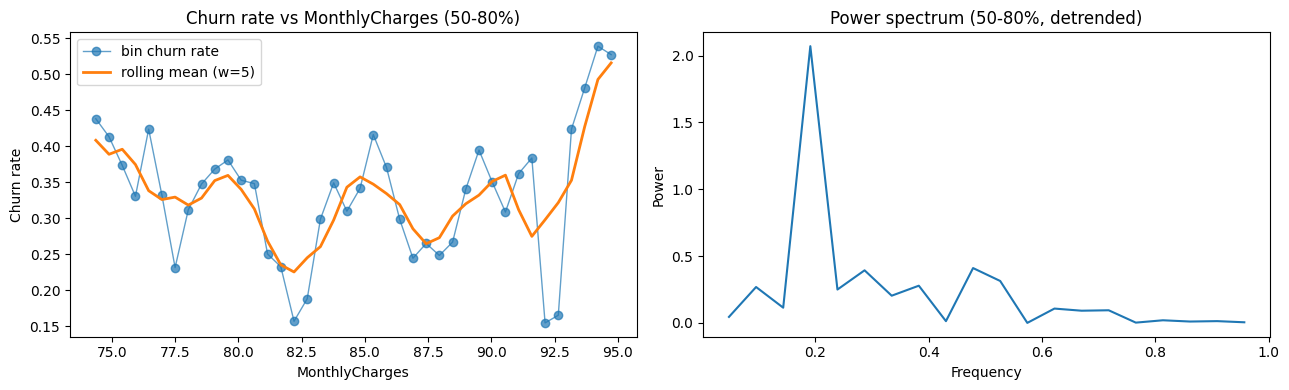

In [ ]:
# # MonthlyChargesの50〜80パーセンタイル帯で周期性を再検証
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # --- 1) 50〜80%帯に限定 ---
# df_band = data_train.copy()
# df_band["Churn_bin"] = df_band["Churn"].map({"No": 0, "Yes": 1})
# q50 = df_band["MonthlyCharges"].quantile(0.5)
# q80 = df_band["MonthlyCharges"].quantile(0.8)
# df_band = df_band[(df_band["MonthlyCharges"] >= q50) & (df_band["MonthlyCharges"] <= q80)].copy()

# print(f"MonthlyCharges 50-80% range: [{q50:.3f}, {q80:.3f}]")
# print(f"rows in band: {len(df_band)}")

# # --- 2) FFT + permutation の関数化 ---
# def periodicity_test(df_in, n_bins=40, n_perm=500, seed=42):
#     bin_edges = np.linspace(df_in["MonthlyCharges"].min(), df_in["MonthlyCharges"].max(), n_bins + 1)
#     tmp = df_in.copy()
#     tmp["charge_bin"] = pd.cut(tmp["MonthlyCharges"], bins=bin_edges, include_lowest=True)

#     agg = (
#         tmp.groupby("charge_bin", observed=False)
#         .agg(churn_rate=("Churn_bin", "mean"), n=("Churn_bin", "size"))
#         .reset_index()
#         .dropna(subset=["churn_rate"])
#         .copy()
#     )
#     agg["bin_center"] = [iv.mid for iv in agg["charge_bin"]]
#     agg = agg.sort_values("bin_center")

#     x = agg["bin_center"].to_numpy()
#     y = agg["churn_rate"].to_numpy()

#     deg = 2 if len(x) >= 8 else 1
#     trend = np.polyval(np.polyfit(x, y, deg=deg), x)
#     resid = y - trend
#     resid = resid - resid.mean()

#     dx = np.mean(np.diff(x))
#     freq = np.fft.rfftfreq(len(resid), d=dx)
#     power = np.abs(np.fft.rfft(resid)) ** 2

#     if len(power) > 1:
#         peak_idx = np.argmax(power[1:]) + 1
#         obs_peak_power = power[peak_idx]
#         peak_freq = freq[peak_idx]
#         est_period = np.inf if peak_freq == 0 else 1.0 / peak_freq
#     else:
#         obs_peak_power = np.nan
#         est_period = np.nan

#     rng = np.random.default_rng(seed)
#     perm_peaks = []
#     for _ in range(n_perm):
#         y_perm = rng.permutation(y)
#         trend_perm = np.polyval(np.polyfit(x, y_perm, deg=deg), x)
#         resid_perm = y_perm - trend_perm
#         resid_perm = resid_perm - resid_perm.mean()
#         pw = np.abs(np.fft.rfft(resid_perm)) ** 2
#         perm_peaks.append(np.max(pw[1:]) if len(pw) > 1 else 0.0)

#     perm_peaks = np.array(perm_peaks)
#     p_value = (np.sum(perm_peaks >= obs_peak_power) + 1) / (n_perm + 1)

#     return {
#         "agg": agg,
#         "freq": freq,
#         "power": power,
#         "p_value": p_value,
#         "est_period": est_period,
#     }

# # --- 3) ビン数依存性の確認 ---
# bin_candidates = [20, 30, 40, 60]
# rows = []
# for b in bin_candidates:
#     out = periodicity_test(df_band, n_bins=b, n_perm=500, seed=42)
#     rows.append({
#         "n_bins": b,
#         "p_value": out["p_value"],
#         "est_period": out["est_period"],
#     })

# result_band = pd.DataFrame(rows)
# display(result_band)

# # 代表として n_bins=40 を可視化
# out40 = periodicity_test(df_band, n_bins=40, n_perm=500, seed=42)
# agg40 = out40["agg"]
# agg40["rolling"] = agg40["churn_rate"].rolling(window=5, center=True, min_periods=1).mean()

# print(f"\nRepresentative (n_bins=40): p-value={out40['p_value']:.4f}, est_period={out40['est_period']:.3f}")
# if out40["p_value"] < 0.05:
#     print("=> 50〜80%帯で周期性が有意")
# else:
#     print("=> 50〜80%帯でも明確な周期性は有意でない")

# fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# axes[0].plot(agg40["bin_center"], agg40["churn_rate"], marker="o", linewidth=1, alpha=0.7, label="bin churn rate")
# axes[0].plot(agg40["bin_center"], agg40["rolling"], linewidth=2, label="rolling mean (w=5)")
# axes[0].set_title("Churn rate vs MonthlyCharges (50-80%)")
# axes[0].set_xlabel("MonthlyCharges")
# axes[0].set_ylabel("Churn rate")
# axes[0].legend()

# axes[1].plot(out40["freq"][1:], out40["power"][1:], linewidth=1.5)
# axes[1].set_title("Power spectrum (50-80%, detrended)")
# axes[1].set_xlabel("Frequency")
# axes[1].set_ylabel("Power")

# plt.tight_layout()
# plt.show()

In [ ]:
# # 追加検証: binの切り位置（オフセット）に対する頑健性チェック
# import numpy as np
# import pandas as pd

# x_raw = df_band["MonthlyCharges"].to_numpy()
# y_raw = df_band["Churn_bin"].to_numpy()

# n_bins = 40
# x_min, x_max = x_raw.min(), x_raw.max()
# bin_width = (x_max - x_min) / n_bins

# rng = np.random.default_rng(123)
# offsets = rng.uniform(0, bin_width, size=20)

# summary = []
# for i, off in enumerate(offsets, start=1):
#     # オフセット付きでbin作成
#     edges = np.linspace(x_min + off, x_max + off, n_bins + 1)

#     # 範囲外を避けるため、両端を拡張
#     edges[0] = min(edges[0], x_min - 1e-9)
#     edges[-1] = max(edges[-1], x_max + 1e-9)

#     tmp = pd.DataFrame({"x": x_raw, "y": y_raw})
#     tmp["bin"] = pd.cut(tmp["x"], bins=edges, include_lowest=True)
#     agg = (
#         tmp.groupby("bin", observed=False)
#         .agg(churn_rate=("y", "mean"), n=("y", "size"))
#         .reset_index()
#         .dropna(subset=["churn_rate"])
#     )
#     agg["center"] = [iv.mid for iv in agg["bin"]]
#     agg = agg.sort_values("center")

#     x = agg["center"].to_numpy()
#     y = agg["churn_rate"].to_numpy()

#     deg = 2 if len(x) >= 8 else 1
#     trend = np.polyval(np.polyfit(x, y, deg=deg), x)
#     resid = y - trend
#     resid = resid - resid.mean()

#     dx = np.mean(np.diff(x))
#     freq = np.fft.rfftfreq(len(resid), d=dx)
#     power = np.abs(np.fft.rfft(resid)) ** 2

#     if len(power) <= 1:
#         summary.append({"offset_idx": i, "p_value": np.nan, "est_period": np.nan})
#         continue

#     peak_idx = np.argmax(power[1:]) + 1
#     obs_peak = power[peak_idx]
#     peak_freq = freq[peak_idx]
#     est_period = np.inf if peak_freq == 0 else 1.0 / peak_freq

#     # permutation
#     perm = []
#     for _ in range(300):
#         yp = rng.permutation(y)
#         tp = np.polyval(np.polyfit(x, yp, deg=deg), x)
#         rp = yp - tp
#         rp = rp - rp.mean()
#         pw = np.abs(np.fft.rfft(rp)) ** 2
#         perm.append(np.max(pw[1:]) if len(pw) > 1 else 0.0)

#     perm = np.array(perm)
#     p_val = (np.sum(perm >= obs_peak) + 1) / (len(perm) + 1)

#     summary.append({"offset_idx": i, "p_value": p_val, "est_period": est_period})

# offset_df = pd.DataFrame(summary)
# print("Offset sensitivity (n_bins=40)")
# display(offset_df)
# print(f"p<0.05 count: {(offset_df['p_value'] < 0.05).sum()} / {len(offset_df)}")
# print(f"median p-value: {offset_df['p_value'].median():.4f}")

Offset sensitivity (n_bins=40)


,offset_idx,p_value,est_period
0,1,0.029900,5.270897
1,2,0.033223,5.228718
2,3,0.033223,5.239872
3,4,0.043189,5.237436
4,5,0.049834,5.236923
5,6,0.019934,5.279487
6,7,0.019934,5.286923
7,8,0.029900,5.243718
8,9,0.016611,5.280000
9,10,0.026578,5.284744


p<0.05 count: 20 / 20
median p-value: 0.0299


## TenureとContractの統合検討

In [ ]:
# # ydata profilingの結果、Partner と Dependandsが高い相関を示しているが特徴量を減らすことはできるか？
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.impute import SimpleImputer
# from sklearn.linear_model import LogisticRegression

# # df: 学習用データフレームを想定
# # target列
# target_col = "Churn"

# # 目的変数を0/1化
# y = df[target_col].map({"No": 0, "Yes": 1}) if df[target_col].dtype == "object" else df[target_col]

# # 特徴量候補（ID列があるなら除外）
# drop_cols = [target_col]
# if "customerID" in df.columns:
#     drop_cols.append("customerID")

# all_features = [c for c in df.columns if c not in drop_cols]

# def cv_auc(features):
#     X = df[features].copy()
#     cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
#     num_cols = [c for c in X.columns if c not in cat_cols]

#     pre = ColumnTransformer(
#         transformers=[
#             ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
#             ("cat", Pipeline([
#                 ("imp", SimpleImputer(strategy="most_frequent")),
#                 ("ohe", OneHotEncoder(handle_unknown="ignore"))
#             ]), cat_cols),
#         ],
#         remainder="drop"
#     )

#     model = Pipeline([
#         ("pre", pre),
#         ("clf", LogisticRegression(max_iter=3000, random_state=42))
#     ])

#     cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
#     return scores.mean(), scores.std()

# scenarios = {
#     "both": all_features,
#     "drop_partner": [c for c in all_features if c != "Partner"],
#     "drop_dependents": [c for c in all_features if c != "Dependents"],
# }

# for name, feats in scenarios.items():
#     mean_auc, std_auc = cv_auc(feats)
#     print(f"{name:15s} AUC = {mean_auc:.5f} ± {std_auc:.5f}")

both            AUC = 0.90755 ± 0.00111
drop_partner    AUC = 0.90761 ± 0.00110
drop_dependents AUC = 0.90731 ± 0.00106


# モデル作成準備

### 目的変数とカテゴリ変数の処理

In [ ]:
# Churnを0,1に変換
data_all['Churn'] = data_all['Churn'].replace({'No': 0, 'Yes': 1})
data_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 848849 entries, 0 to 254654
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                848849 non-null  int64  
 1   gender            848849 non-null  object 
 2   SeniorCitizen     848849 non-null  int64  
 3   tenure            848849 non-null  int64  
 4   InternetService   848849 non-null  object 
 5   OnlineSecurity    848849 non-null  object 
 6   OnlineBackup      848849 non-null  object 
 7   DeviceProtection  848849 non-null  object 
 8   TechSupport       848849 non-null  object 
 9   StreamingTV       848849 non-null  object 
 10  StreamingMovies   848849 non-null  object 
 11  Contract          848849 non-null  object 
 12  PaperlessBilling  848849 non-null  object 
 13  PaymentMethod     848849 non-null  object 
 14  MonthlyCharges    848849 non-null  float64
 15  TotalCharges      848849 non-null  float64
 16  Churn             594194 

In [ ]:
# カテゴリ変数（Churn以外）をOne-Hotエンコーディング
cat_cols = data_all.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Churn']

print('対象カテゴリ列:', cat_cols)

data_all = pd.get_dummies(data_all, columns=cat_cols, drop_first=True)

print('変換後 shape:', data_all.shape)
print('欠損数合計:', data_all.isnull().sum().sum())

対象カテゴリ列: ['gender', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'PhoneLineStatus', 'HouseholdType']
変換後 shape: (848849, 32)
欠損数合計: 254655


In [ ]:
# 不要な列を削除
drop_columns = ['id']  # ID列は常に削除
data_all.drop(drop_columns, axis=1, inplace=True)
print(f"削除後の列数: {len(data_all.columns)}")
print(f"欠損値:\n{data_all.isnull().sum()[data_all.isnull().sum() > 0]}")

削除後の列数: 31
欠損値:
Churn    254655
dtype: int64


In [ ]:
# 結合したデータを、再度、教師データとテストデータに分ける
# len()で行数を取得、スライスで分割
train_len = len(data_train)
data_all_train = data_all[:train_len]
data_all_test = data_all[train_len:]

print(f"教師データ: {data_all_train.shape}")
print(f"テストデータ: {data_all_test.shape}")

教師データ: (594194, 31)
テストデータ: (254655, 31)


In [ ]:
# 目的変数と説明変数を分離（アルゴリズムに投入するための準備）
# y: 目的変数（Churn）、x: 説明変数（それ以外）
target = 'Churn'

# 教師データの分離
y_train = data_all_train[target]
x_train = data_all_train.drop(target, axis=1)

# テストデータの分離（テストにはChurnがない想定だが、念のため確認）
if target in data_all_test.columns:
    y_test = data_all_test[target]
    x_test = data_all_test.drop(target, axis=1)
else:
    x_test = data_all_test.copy()
    print(f"テストデータにはChurn列がありません")

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}")

x_train: (594194, 30), y_train: (594194,)
x_test: (254655, 30)


# モデル作成1 Logistic Regression

In [ ]:
# Logistic Regressionで学習（文字列列が残っていても学習できるように数値化）
from sklearn.linear_model import LogisticRegression

x_train_model = pd.get_dummies(x_train, drop_first=True)
x_test_model = pd.get_dummies(x_test, drop_first=True)

# 学習時と推論時で列を揃える
x_train_model, x_test_model = x_train_model.align(x_test_model, join='left', axis=1, fill_value=0)

# 目的変数を分類用の0/1整数に正規化（学習用ラベル）
y_train_cls = pd.Series(y_train).replace({'No': 0, 'Yes': 1})
y_train_cls = pd.to_numeric(y_train_cls, errors='coerce')
if y_train_cls.isnull().any():
    bad_count = int(y_train_cls.isnull().sum())
    raise ValueError(f'y_train に変換不能な値が {bad_count} 件あります。前処理セルを確認してください。')
y_train_cls = y_train_cls.astype(int)

clf_lr = LogisticRegression(
    max_iter=3000,
    random_state=42,
    solver='liblinear'
)

clf_lr.fit(x_train_model, y_train_cls)
print('Logistic Regression モデルの学習完了')
print('train shape:', x_train_model.shape)
print('test shape :', x_test_model.shape)
print('class balance:', y_train_cls.value_counts().to_dict())

Logistic Regression モデルの学習完了
train shape: (594194, 30)
test shape : (254655, 30)
class balance: {0: 460377, 1: 133817}


# モデル作成2 Random Forest

In [ ]:
# Random Forest アルゴリズムをインポート
# 複数の決定木を組み合わせて予測精度を高める手法
from sklearn.ensemble import RandomForestClassifier

# Logistic Regressionセルを実行していない場合に備えて、ここでも特徴量を数値化
x_train_model = pd.get_dummies(x_train, drop_first=True)
x_test_model = pd.get_dummies(x_test, drop_first=True)
x_train_model, x_test_model = x_train_model.align(x_test_model, join='left', axis=1, fill_value=0)

# 目的変数を分類用の0/1整数に正規化（学習用ラベル）
y_train_cls = pd.Series(y_train).replace({'No': 0, 'Yes': 1})
y_train_cls = pd.to_numeric(y_train_cls, errors='coerce')
if y_train_cls.isnull().any():
    bad_count = int(y_train_cls.isnull().sum())
    raise ValueError(f'y_train に変換不能な値が {bad_count} 件あります。前処理セルを確認してください。')
y_train_cls = y_train_cls.astype(int)

clf_rf = RandomForestClassifier(
    n_estimators=100,      # 決定木の本数
    max_depth=10,          # 決定木の最大深さ
    random_state=42,       # 乱数シード（再現性のため）
    n_jobs=-1              # 並列処理（全CPUコア使用）
)

# 教師データで学習
clf_rf.fit(x_train_model, y_train_cls)
print('RandomForest モデルの学習完了')
print('train shape:', x_train_model.shape)
print('test shape :', x_test_model.shape)
print('class balance:', y_train_cls.value_counts().to_dict())

RandomForest モデルの学習完了
train shape: (594194, 30)
test shape : (254655, 30)
class balance: {0: 460377, 1: 133817}


In [ ]:
# テストデータにモデルを適用して確率を予測
# model_name は 'rf' または 'lr' を指定
model_name = 'rf'

if model_name == 'rf':
    if 'clf_rf' not in dir():
        raise NameError("clf_rf が見つかりません。Random Forest学習セルを先に実行してください。")
    model = clf_rf
elif model_name == 'lr':
    if 'clf_lr' not in dir():
        raise NameError("clf_lr が見つかりません。Logistic Regression学習セルを先に実行してください。")
    model = clf_lr
else:
    raise ValueError("model_name は 'rf' か 'lr' を指定してください。")

y_pred_proba = model.predict_proba(x_test_model)[:, 1]

print('model_name:', model_name)
print('予測件数:', len(y_pred_proba))
print('先頭10件(確率):', y_pred_proba[:10])

予測件数: 254655
先頭10件(クラス): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
先頭10件(確率): [1.05155259e-01 3.16912528e-04 1.62490663e-01 1.02640792e-02
 4.92006313e-01 1.70603669e-01 5.93318434e-01 3.70259446e-03
 6.25936399e-02 2.43690039e-01]


# Submit

In [ ]:
# 提出用CSVを作成（Churnを確率値で出力）
if 'data_submission' in dir():
    submit = data_submission.copy()
    submit['Churn'] = pd.Series(y_pred_proba, index=submit.index).astype('float64')

    file_suffix = model_name if 'model_name' in dir() else 'model'
    output_file = f'{file_suffix}_proba_submission.csv'
    submit.to_csv(output_file, index=False)

    print(f'提出ファイル作成完了: {output_file}')
    print(f'行数: {len(submit)}')
    print('Churn dtype:', submit['Churn'].dtype)
    print(submit['Churn'].head())
else:
    print('data_submission が見つかりません')

提出ファイル作成完了: randomforest_churn_submission.csv
行数: 254655
Churn dtype: int64
0    0
1    0
2    0
3    0
4    1
Name: Churn, dtype: int64
